# **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

In [4]:
!pip install -q xgboost

In [5]:
import xgboost as xgb
from xgboost import XGBClassifier

In [6]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

In [7]:
!pip install -q catboost

In [8]:
import catboost
from catboost import CatBoostClassifier

In [9]:
!pip install -q lightgbm

In [10]:
import lightgbm
from lightgbm import LGBMClassifier

In [11]:
print("xgboost:", xgb.__version__)
print("catboost:", catboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("joblib:", joblib.__version__)

xgboost: 3.1.2
catboost: 1.2.8
lightgbm: 4.6.0
joblib: 1.4.2


# **Dataset**

In [12]:
data_set = pd.read_csv('genres_v2.csv', low_memory = False)

# **Exploratory Data Analysis**

In [13]:
df_org = data_set.copy()

In [14]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  type              42305 non-null  object 
 12  id                42305 non-null  object 
 13  uri               42305 non-null  object 
 14  track_href        42305 non-null  object 
 15  analysis_url      42305 non-null  object 
 16  duration_ms       42305 non-null  int64 

In [15]:
df_org.sample(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
33093,0.681,0.809,9,-5.902,1,0.1370,0.000255,0.672000,0.0974,0.1540,...,4Gg2GKkkrYggy6gWCfUpeX,spotify:track:4Gg2GKkkrYggy6gWCfUpeX,https://api.spotify.com/v1/tracks/4Gg2GKkkrYgg...,https://api.spotify.com/v1/audio-analysis/4Gg2...,374573,4,psytrance,NaN,11675.0,PSYTRANCE BANGERS best new 2020
37268,0.480,0.767,1,-6.618,1,0.2530,0.024200,0.000003,0.0851,0.2700,...,4VVjzngAalHfFGOgnpn5n1,spotify:track:4VVjzngAalHfFGOgnpn5n1,https://api.spotify.com/v1/tracks/4VVjzngAalHf...,https://api.spotify.com/v1/audio-analysis/4VVj...,305686,4,dnb,NaN,15869.0,Liqduicity Drum & Bass
24225,0.798,0.952,7,-4.429,1,0.0498,0.012300,0.422000,0.0876,0.5340,...,5MApVTEXZD7elsoCiN43XS,spotify:track:5MApVTEXZD7elsoCiN43XS,https://api.spotify.com/v1/tracks/5MApVTEXZD7e...,https://api.spotify.com/v1/audio-analysis/5MAp...,218053,4,techhouse,NaN,2723.0,Dirtybird House
29550,0.636,0.739,10,-7.443,0,0.4450,0.019100,0.688000,0.2350,0.1420,...,5c9XAgWPoBTDC8D47YeOCP,spotify:track:5c9XAgWPoBTDC8D47YeOCP,https://api.spotify.com/v1/tracks/5c9XAgWPoBTD...,https://api.spotify.com/v1/audio-analysis/5c9X...,408750,4,trance,NaN,8094.0,Progressive Trance
14871,0.686,0.648,1,-6.055,1,0.0913,0.049100,0.000000,0.3820,0.0538,...,2cSqeOJIaFPEF7N5J7xiIZ,spotify:track:2cSqeOJIaFPEF7N5J7xiIZ,https://api.spotify.com/v1/tracks/2cSqeOJIaFPE...,https://api.spotify.com/v1/audio-analysis/2cSq...,159556,4,Rap,The Jungle Book,NaN,NaN
33749,0.728,0.760,7,-4.285,1,0.0395,0.001520,0.003910,0.1100,0.6890,...,2HcM8iwkJBv1uvAX675ukf,spotify:track:2HcM8iwkJBv1uvAX675ukf,https://api.spotify.com/v1/tracks/2HcM8iwkJBv1...,https://api.spotify.com/v1/audio-analysis/2HcM...,324928,4,trap,NaN,12334.0,Headbangers:Dubstep/Riddim
33858,0.630,0.888,4,-1.172,1,0.1870,0.192000,0.058500,0.1200,0.0645,...,2LZkfbnLzUxyOyDluDlQ9v,spotify:track:2LZkfbnLzUxyOyDluDlQ9v,https://api.spotify.com/v1/tracks/2LZkfbnLzUxy...,https://api.spotify.com/v1/audio-analysis/2LZk...,230400,4,trap,NaN,12444.0,Riddim Dubstep 2017-2018-2019
10175,0.570,0.962,10,-1.581,0,0.4210,0.071100,0.000000,0.0748,0.7540,...,7ighctS1exCe8hJXTEkNen,spotify:track:7ighctS1exCe8hJXTEkNen,https://api.spotify.com/v1/tracks/7ighctS1exCe...,https://api.spotify.com/v1/audio-analysis/7igh...,232493,4,Underground Rap,Timeless (feat. Lil Wayne & Big Sean),NaN,NaN
18293,0.561,0.667,4,-5.191,0,0.0508,0.586000,0.000000,0.1160,0.3850,...,5Ux410GeRXrojeP0vUPx6v,spotify:track:5Ux410GeRXrojeP0vUPx6v,https://api.spotify.com/v1/tracks/5Ux410GeRXro...,https://api.spotify.com/v1/audio-analysis/5Ux4...,241688,4,Pop,Take Me To Church,NaN,NaN
178,0.628,0.530,10,-9.663,0,0.0855,0.060800,0.000000,0.0642,0.2030,...,4rLltALU0JVawcOAA88bnQ,spotify:track:4rLltALU0JVawcOAA88bnQ,https://api.spotify.com/v1/tracks/4rLltALU0JVa...,https://api.spotify.com/v1/audio-analysis/4rLl...,162000,4,Dark Trap,Afterlife,NaN,NaN


In [16]:
df = df_org.drop(['id', 'uri', 'track_href', 'analysis_url', 'song_name', 'Unnamed: 0', 'title'], axis = 1)

In [17]:
df.sample(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,genre
31226,0.629,0.977,6,-5.680,1,0.0556,0.000034,0.782000,0.1040,0.0777,144.990,audio_features,446897,4,psytrance
6265,0.855,0.586,6,-7.134,1,0.1670,0.200000,0.000000,0.2530,0.7510,138.132,audio_features,85217,4,Underground Rap
871,0.713,0.813,8,-5.429,1,0.1680,0.046500,0.000000,0.1870,0.1960,152.020,audio_features,199001,4,Dark Trap
14882,0.938,0.559,10,-6.734,1,0.3120,0.054600,0.000000,0.1570,0.7600,119.901,audio_features,141040,4,Rap
20540,0.600,0.723,6,-4.928,0,0.1580,0.109000,0.000000,0.1670,0.4630,149.881,audio_features,195268,4,Hiphop
3947,0.517,0.804,5,-6.476,1,0.0546,0.001740,0.884000,0.2340,0.0658,169.987,audio_features,321882,4,Dark Trap
13383,0.432,0.690,9,-4.772,1,0.0292,0.092700,0.000043,0.1840,0.2640,177.594,audio_features,222493,4,Emo
9801,0.427,0.679,1,-8.405,1,0.3440,0.001030,0.000000,0.1590,0.3110,137.398,audio_features,159518,3,Underground Rap
16340,0.901,0.371,9,-5.492,0,0.1080,0.048400,0.000000,0.0978,0.7520,200.028,audio_features,219973,4,RnB
27727,0.533,0.979,7,-8.179,1,0.0839,0.000678,0.916000,0.0946,0.0586,139.988,audio_features,473143,4,trance


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  type              42305 non-null  object 
 12  duration_ms       42305 non-null  int64  
 13  time_signature    42305 non-null  int64  
 14  genre             42305 non-null  object 
dtypes: float64(9), int64(4), object(2)
memory usage: 4.8+ MB


In [19]:
df['type'].value_counts()

type
audio_features    42305
Name: count, dtype: int64

In [20]:
df = df.drop('type', axis = 1)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  duration_ms       42305 non-null  int64  
 12  time_signature    42305 non-null  int64  
 13  genre             42305 non-null  object 
dtypes: float64(9), int64(4), object(1)
memory usage: 4.5+ MB


In [22]:
int_columns = df.select_dtypes('int').columns
df[int_columns] = df[int_columns].astype('float')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  float64
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  float64
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  duration_ms       42305 non-null  float64
 12  time_signature    42305 non-null  float64
 13  genre             42305 non-null  object 
dtypes: float64(13), object(1)
memory usage: 4.5+ MB


In [24]:
numeric_columns = df.select_dtypes(include = 'number').columns
n_cols = 5
n_rows = int(np.ceil(len(numeric_columns)/n_cols))
n_rows

3

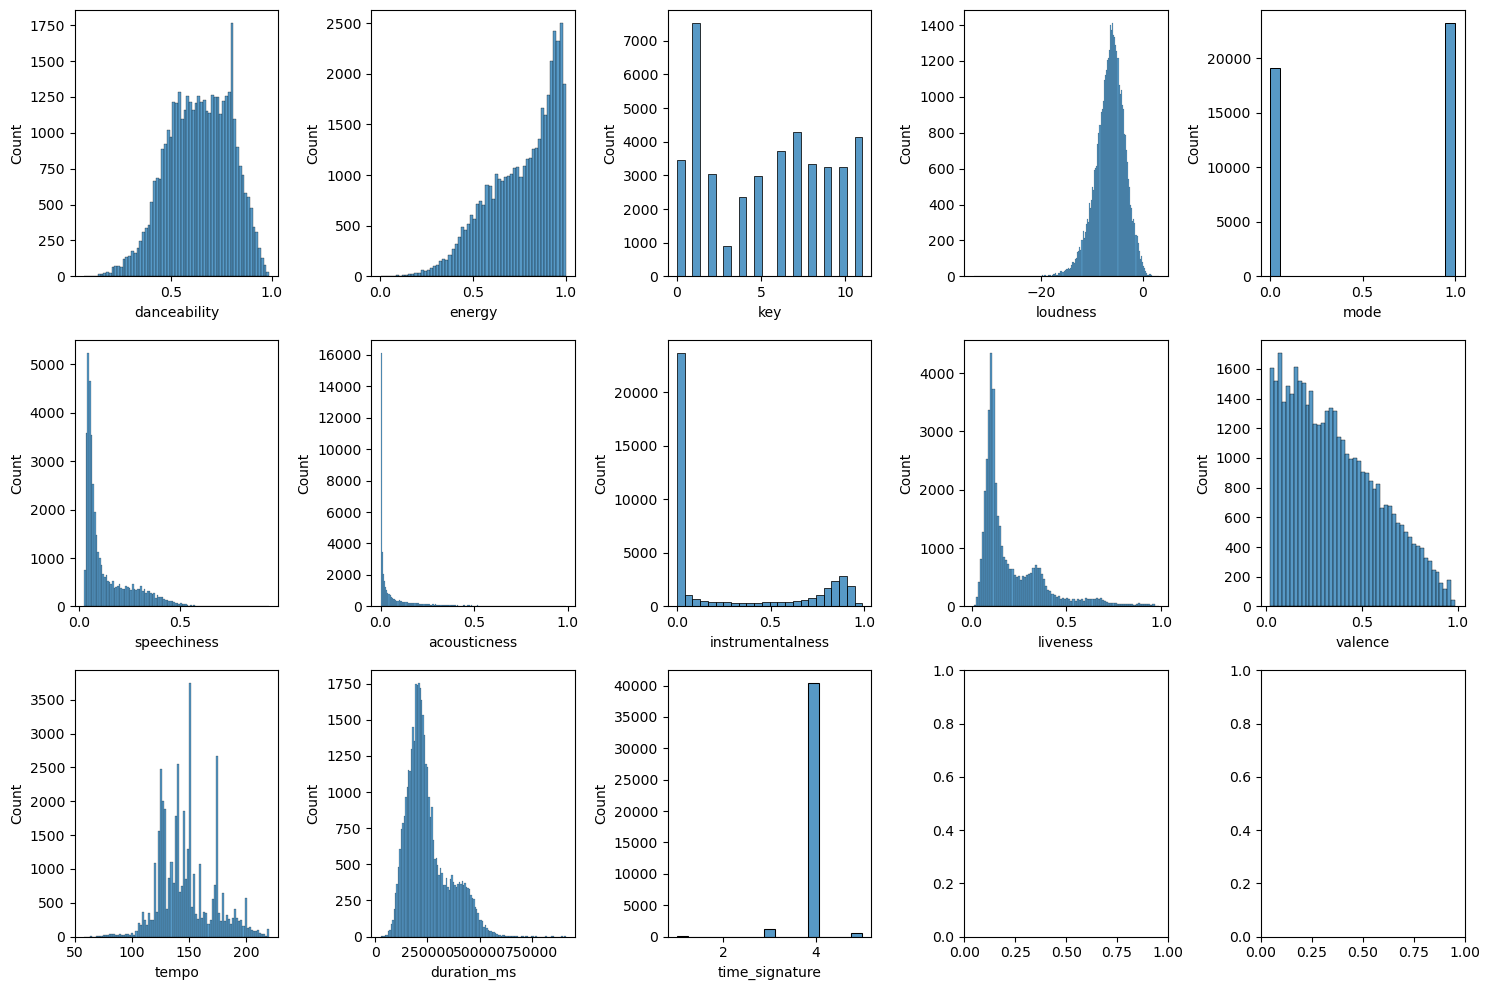

In [25]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (15,10))
axes = axes.flatten()
for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], ax = axes[i])
plt.tight_layout()
plt.show()

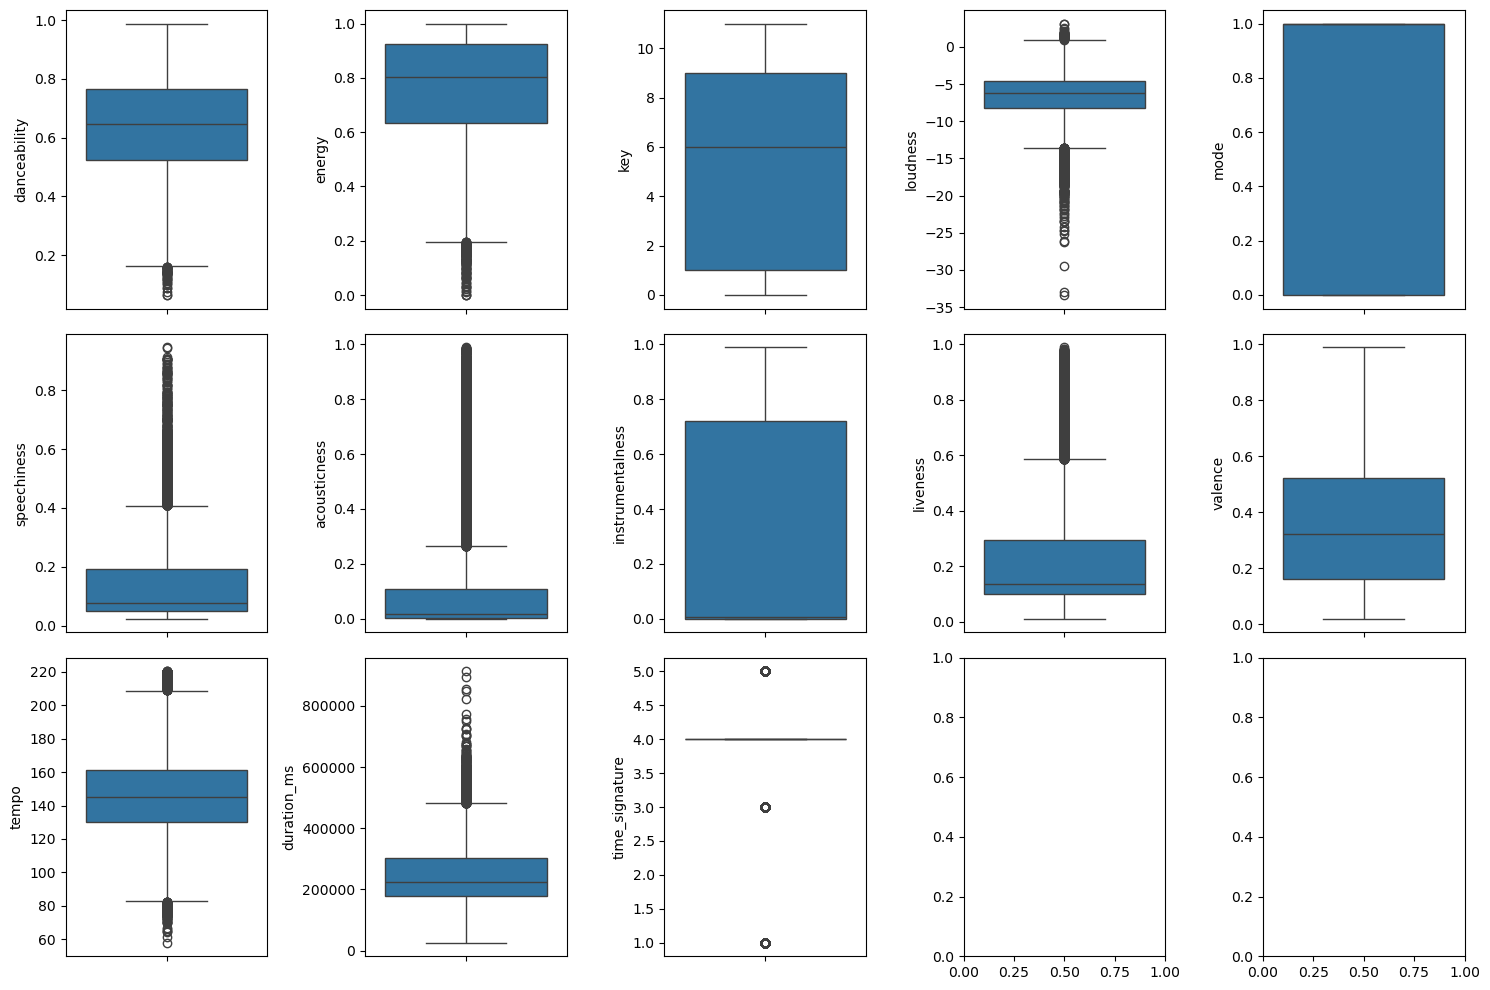

In [26]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (15,10))
axes = axes.flatten()
for i, col in enumerate(numeric_columns):
    sns.boxplot(df[col], ax = axes[i])
plt.tight_layout()
plt.show()

# **Label Encoding of the Target Variable**

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['genre'])

In [28]:
df[['genre', 'genre_encoded']].sample(20)

,genre,genre_encoded
6302,Underground Rap,7
36918,dnb,8
15604,Rap,4
25373,techno,12
20612,Hiphop,2
3336,Dark Trap,0
17958,RnB,5
13084,Emo,1
26844,techno,12
19631,Hiphop,2


In [29]:
df = df.sample(4000)

# **Train Test Split**

In [30]:
X = df.drop(['genre', 'genre_encoded'], axis = 1)
y = df['genre_encoded']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [32]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3200, 13), (800, 13), (3200,), (800,))

In [33]:
y.value_counts()

genre_encoded
7     577
0     423
13    306
11    297
8     291
12    278
9     271
14    270
2     270
10    269
6     203
5     189
1     170
4     147
3      39
Name: count, dtype: int64

In [34]:
X_train.sample(20)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
8378,0.675,0.491,0.0,-9.232,0.0,0.7700,0.128000,0.000000,0.2000,0.5160,107.292,166687.0,5.0
10448,0.735,0.469,2.0,-12.368,1.0,0.3830,0.451000,0.000178,0.1270,0.5860,159.968,61500.0,4.0
21879,0.835,0.976,1.0,-3.617,0.0,0.1110,0.001300,0.000053,0.2520,0.4400,125.009,276955.0,4.0
278,0.656,0.572,2.0,-8.210,1.0,0.0627,0.022800,0.093500,0.1640,0.1760,159.843,168008.0,4.0
16858,0.600,0.632,2.0,-6.062,0.0,0.4290,0.173000,0.000000,0.1080,0.3330,165.072,179332.0,4.0
8021,0.522,0.521,10.0,-13.096,0.0,0.8680,0.247000,0.000000,0.1250,0.6830,173.739,162759.0,4.0
31607,0.576,0.970,1.0,-6.115,1.0,0.0821,0.000354,0.769000,0.2900,0.3520,143.999,460000.0,4.0
11011,0.361,0.794,11.0,-5.595,0.0,0.0650,0.025600,0.000000,0.3320,0.2230,155.620,150152.0,4.0
6953,0.370,0.856,7.0,-5.489,1.0,0.4010,0.403000,0.009670,0.1800,0.0755,158.764,236301.0,5.0
30734,0.467,0.889,11.0,-5.355,0.0,0.1140,0.002370,0.502000,0.1130,0.0396,140.007,378857.0,4.0


In [35]:
min_values = df.min()
max_values = df.max()

print("Minimum values:\n", min_values)
print("\nMaximum values:\n", max_values)

Minimum values:
 danceability           0.0651
energy                 0.0223
key                       0.0
loudness              -22.534
mode                      0.0
speechiness            0.0232
acousticness         0.000003
instrumentalness          0.0
liveness               0.0205
valence                0.0218
tempo                  64.934
duration_ms           43807.0
time_signature            1.0
genre               Dark Trap
genre_encoded               0
dtype: object

Maximum values:
 danceability           0.988
energy                 0.999
key                     11.0
loudness               1.313
mode                     1.0
speechiness            0.905
acousticness           0.976
instrumentalness       0.981
liveness               0.988
valence                0.976
tempo                220.138
duration_ms         752000.0
time_signature           5.0
genre                   trap
genre_encoded             14
dtype: object


# **Scaling**

In [36]:
scaler = StandardScaler()
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [37]:
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

# **Metric Selection Rationale**
When predicting genre, we want our model to correctly identify as many true genres as possible (high recall) while also ensuring that its predictions are correct (high precision). With imbalanced classes, some genres have many more samples than others, so a model could achieve high overall accuracy by mostly predicting the most common genres and ignoring the rare ones. The Macro F1 score may be a fair and informative metric for this goal because:

1) It calculates the F1 score for each genre/class separately
2) It averages all these F1 scores across all genres, so each genre contributes equally, regardless of how many samples it has

Macro F1, balances both precision and recall across all classes and is well-suited for imbalanced multiclass classification

# **Logistic Classification**

In [38]:
logr = LogisticRegression(max_iter = 5000)
logr.fit(X_train_sc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [39]:
f1_score(y_train, logr.predict(X_train_sc), average='macro'), f1_score(y_test, logr.predict(X_test_sc), average='macro')

(0.5291406819901431, 0.5084787144589566)

### **GridSearch**

In [40]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100],
              'max_iter': [10000],
              'penalty': ['l1', 'l2'],
              'solver': ['liblinear', 'lbfgs', 'saga', 'sag'],
              'class_weight': [None, 'balanced']}
logr_grid = GridSearchCV(logr, param_grid = param_grid, cv =5, n_jobs = -1, scoring = 'f1_macro')
logr_grid.fit(X_train_sc, y_train)

C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
100 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solver =

,estimator,LogisticRegre...max_iter=5000)
,param_grid,"{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [10000], 'penalty': ['l1', 'l2'], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [41]:
logr_grid.best_score_, logr_grid.best_params_

(np.float64(0.519090248725053),
 {'C': 100,
  'class_weight': None,
  'max_iter': 10000,
  'penalty': 'l1',
  'solver': 'saga'})

In [42]:
logr_all_results = {
    'Regular': {
        'Train Accuracy': accuracy_score(y_train, logr.predict(X_train_sc)),
        'Train F1': f1_score(y_train, logr.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, logr.predict(X_test_sc)),
        'Test F1': f1_score(y_test, logr.predict(X_test_sc), average='macro')
    },
    'Grid Search': {
        'Train Accuracy': accuracy_score(y_train, logr_grid.predict(X_train_sc)),
        'Train F1': f1_score(y_train, logr_grid.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, logr_grid.predict(X_test_sc)),
        'Test F1': f1_score(y_test, logr_grid.predict(X_test_sc), average='macro'),
        'Best CV F1': logr_grid.best_score_
    }
}
logr_all_results

{'Regular': {'Train Accuracy': 0.5884375,
  'Train F1': 0.5291406819901431,
  'Test Accuracy': 0.575,
  'Test F1': 0.5084787144589566},
 'Grid Search': {'Train Accuracy': 0.589375,
  'Train F1': 0.5314310789619828,
  'Test Accuracy': 0.57375,
  'Test F1': 0.5079142923353939,
  'Best CV F1': np.float64(0.519090248725053)}}

# **Support Vectors**

In [43]:
svm = SVC()
svm.fit(X_train_sc, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [44]:
f1_score(y_train, svm.predict(X_train_sc), average='macro'), f1_score(y_test, svm.predict(X_test_sc), average='macro')

(0.6381570518940728, 0.5374872693715965)

### **GridSearch**

In [45]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}
svm_grid = GridSearchCV(svm, param_grid = param_grid, cv = 5, n_jobs = -1, scoring = 'f1_macro')
svm_grid.fit(X_train_sc, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf', 'linear', ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [46]:
svm_grid.best_score_, svm_grid.best_params_

(np.float64(0.5759925066169079), {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'})

In [47]:
svm_all_results = {
    'Regular': {
        'Train Accuracy': accuracy_score(y_train, svm.predict(X_train_sc)),
        'Train F1': f1_score(y_train, svm.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, svm.predict(X_test_sc)),
        'Test F1': f1_score(y_test, svm.predict(X_test_sc), average='macro')
    },
    'Grid Search': {
        'Train Accuracy': accuracy_score(y_train, svm_grid.predict(X_train_sc)),
        'Train F1': f1_score(y_train, svm_grid.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, svm_grid.predict(X_test_sc)),
        'Test F1': f1_score(y_test, svm_grid.predict(X_test_sc), average='macro'),
        'Best CV F1': svm_grid.best_score_
    }
}
svm_all_results

{'Regular': {'Train Accuracy': 0.6971875,
  'Train F1': 0.6381570518940728,
  'Test Accuracy': 0.61,
  'Test F1': 0.5374872693715965},
 'Grid Search': {'Train Accuracy': 0.7415625,
  'Train F1': 0.7073477822989693,
  'Test Accuracy': 0.62375,
  'Test F1': 0.5615028042354384,
  'Best CV F1': np.float64(0.5759925066169079)}}

# **Gradient Bossting**

In [48]:
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train_sc, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [49]:
f1_score(y_train, gbc.predict(X_train_sc), average='macro'), f1_score(y_test, gbc.predict(X_test_sc), average='macro')

(0.9383152940761622, 0.629692890270234)

In [50]:
gbc_feature_importances = pd.Series(gbc.feature_importances_, index=X_train.columns)
gbc_feature_importances

danceability        0.084150
energy              0.037644
key                 0.004424
loudness            0.058455
mode                0.000957
speechiness         0.052314
acousticness        0.044502
instrumentalness    0.096447
liveness            0.023166
valence             0.047607
tempo               0.383555
duration_ms         0.164905
time_signature      0.001873
dtype: float64

### **GridSearch**

In [51]:
param_grid = {
    'n_estimators': [50, 100, 150, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}
gbc_grid = GridSearchCV(gbc, param_grid = param_grid, cv = 5, n_jobs = -1, scoring = 'f1_macro')
gbc_grid.fit(X_train_sc, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [52]:
gbc_grid.best_params_, gbc_grid.best_score_

({'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200},
 np.float64(0.6178354482152464))

In [53]:
gbc_grid_feature_importances = pd.Series(gbc_grid.best_estimator_.feature_importances_, index=X_train.columns)
gbc_grid_feature_importances

danceability        0.076693
energy              0.033939
key                 0.001783
loudness            0.063756
mode                0.000808
speechiness         0.049085
acousticness        0.040894
instrumentalness    0.112150
liveness            0.020427
valence             0.032276
tempo               0.394690
duration_ms         0.172512
time_signature      0.000988
dtype: float64

In [54]:
gbc_all_results = {
    'Regular': {
        'Train Accuracy': accuracy_score(y_train, gbc.predict(X_train_sc)),
        'Train F1': f1_score(y_train, gbc.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, gbc.predict(X_test_sc)),
        'Test F1': f1_score(y_test, gbc.predict(X_test_sc), average='macro')
    },
    'Grid Search': {
        'Train Accuracy': accuracy_score(y_train, gbc_grid.predict(X_train_sc)),
        'Train F1': f1_score(y_train, gbc_grid.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, gbc_grid.predict(X_test_sc)),
        'Test F1': f1_score(y_test, gbc_grid.predict(X_test_sc), average='macro'),
        'Best CV F1': gbc_grid.best_score_
    }
}
gbc_all_results

{'Regular': {'Train Accuracy': 0.9284375,
  'Train F1': 0.9383152940761622,
  'Test Accuracy': 0.695,
  'Test F1': 0.629692890270234},
 'Grid Search': {'Train Accuracy': 0.8975,
  'Train F1': 0.9107712771981018,
  'Test Accuracy': 0.675,
  'Test F1': 0.6124498859144409,
  'Best CV F1': np.float64(0.6178354482152464)}}

# **Random Forest**

In [55]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train_sc, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
f1_score(y_train, rf.predict(X_train_sc), average='macro'), f1_score(y_test, rf.predict(X_test_sc), average='macro')

(0.9937507731925553, 0.6100725201063149)

In [57]:
rf_feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_feature_importances

danceability        0.099515
energy              0.077073
key                 0.034286
loudness            0.083916
mode                0.010279
speechiness         0.076618
acousticness        0.073096
instrumentalness    0.095650
liveness            0.057581
valence             0.072055
tempo               0.189836
duration_ms         0.125424
time_signature      0.004672
dtype: float64

### **GridSearch**

In [58]:
param_grid = {
    'n_estimators': [50, 100, 200, 500, 700, 1000],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10, 20, 30]
}
rf_grid = GridSearchCV(rf, param_grid, cv = 5, n_jobs = -1, scoring = 'f1_macro')
rf_grid.fit(X_train_sc, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,700


In [59]:
rf_grid.best_score_, rf_grid.best_params_

(np.float64(0.619757932897475),
 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 700})

In [60]:
rf_grid_feature_importances = pd.Series(rf_grid.best_estimator_.feature_importances_, index=X_train.columns)
rf_grid_feature_importances

danceability        0.099661
energy              0.077727
key                 0.033481
loudness            0.084059
mode                0.010621
speechiness         0.076929
acousticness        0.071908
instrumentalness    0.094010
liveness            0.058326
valence             0.071412
tempo               0.189462
duration_ms         0.127773
time_signature      0.004632
dtype: float64

In [61]:
rf_all_results = {
    'Regular': {
        'Train Accuracy': accuracy_score(y_train, rf.predict(X_train_sc)),
        'Train F1': f1_score(y_train, rf.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, rf.predict(X_test_sc)),
        'Test F1': f1_score(y_test, rf.predict(X_test_sc), average='macro')
    },
    'Grid Search': {
        'Train Accuracy': accuracy_score(y_train, rf_grid.predict(X_train_sc)),
        'Train F1': f1_score(y_train, rf_grid.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, rf_grid.predict(X_test_sc)),
        'Test F1': f1_score(y_test, rf_grid.predict(X_test_sc), average='macro'),
        'Best CV F1': rf_grid.best_score_
    }
}
rf_all_results

{'Regular': {'Train Accuracy': 0.99375,
  'Train F1': 0.9937507731925553,
  'Test Accuracy': 0.67,
  'Test F1': 0.6100725201063149},
 'Grid Search': {'Train Accuracy': 0.99375,
  'Train F1': 0.993904221942199,
  'Test Accuracy': 0.685,
  'Test F1': 0.6198747506812825,
  'Best CV F1': np.float64(0.619757932897475)}}

# **K-Neighbors**

In [62]:
knn = KNeighborsClassifier()
knn.fit(X_train_sc, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [63]:
f1_score(y_train, knn.predict(X_train_sc), average='macro'), f1_score(y_test, knn.predict(X_test_sc), average='macro')

(0.6120732361393274, 0.4356754548755649)

### **GridSearch**

In [64]:
param_grid = {
    'n_neighbors': range(1, 11),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
knn_grid = GridSearchCV(knn, param_grid, cv = 5, n_jobs = -1, scoring = 'f1_macro')
knn_grid.fit(X_train_sc, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': range(1, 11), 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [65]:
knn_grid.best_score_, knn_grid.best_params_

(np.float64(0.4951401626623662),
 {'n_neighbors': 9, 'p': 1, 'weights': 'distance'})

In [66]:
knn_all_results = {
    'Regular': {
        'Train Accuracy': accuracy_score(y_train, knn.predict(X_train_sc)),
        'Train F1': f1_score(y_train, knn.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, knn.predict(X_test_sc)),
        'Test F1': f1_score(y_test, knn.predict(X_test_sc), average='macro')
    },
    'Grid Search': {
        'Train Accuracy': accuracy_score(y_train, knn_grid.predict(X_train_sc)),
        'Train F1': f1_score(y_train, knn_grid.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, knn_grid.predict(X_test_sc)),
        'Test F1': f1_score(y_test, knn_grid.predict(X_test_sc), average='macro'),
        'Best CV F1': knn_grid.best_score_
    }
}
knn_all_results

{'Regular': {'Train Accuracy': 0.654375,
  'Train F1': 0.6120732361393274,
  'Test Accuracy': 0.49625,
  'Test F1': 0.4356754548755649},
 'Grid Search': {'Train Accuracy': 0.99375,
  'Train F1': 0.9938187644404329,
  'Test Accuracy': 0.5925,
  'Test F1': 0.5284159383881116,
  'Best CV F1': np.float64(0.4951401626623662)}}

# **XGBoost**

In [67]:
xgbc = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgbc.fit(X_train_sc, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [68]:
f1_score(y_train, xgbc.predict(X_train_sc), average='macro'), f1_score(y_test, xgbc.predict(X_test_sc), average='macro')

(0.9937773772620788, 0.623482841428532)

In [69]:
xgbc_feature_importances = pd.Series(xgbc.feature_importances_, index=X_train.columns)
xgbc_feature_importances

danceability        0.080068
energy              0.060476
key                 0.028693
loudness            0.060306
mode                0.034599
speechiness         0.055170
acousticness        0.045264
instrumentalness    0.133228
liveness            0.034152
valence             0.055157
tempo               0.234359
duration_ms         0.144994
time_signature      0.033535
dtype: float32

### **GridSearch**

In [70]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
xgbc_grid = GridSearchCV(xgbc, param_grid = param_grid, cv = 5, n_jobs = -1, scoring = 'f1_macro')
xgbc_grid.fit(X_train_sc, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100], 'subsample': [0.8, 1.0]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [71]:
xgbc_grid.best_score_, xgbc_grid.best_params_

(np.float64(0.6254509979010241),
 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1.0})

In [72]:
xgbc_grid_feature_importances = pd.Series(xgbc_grid.best_estimator_.feature_importances_, index=X_train.columns)
xgbc_grid_feature_importances

danceability        0.093048
energy              0.058666
key                 0.024108
loudness            0.076153
mode                0.031551
speechiness         0.059022
acousticness        0.044043
instrumentalness    0.125275
liveness            0.034652
valence             0.056417
tempo               0.208723
duration_ms         0.161874
time_signature      0.026468
dtype: float32

In [73]:
xgbc_all_results = {
    'Regular': {
        'Train Accuracy': accuracy_score(y_train, xgbc.predict(X_train_sc)),
        'Train F1': f1_score(y_train, xgbc.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, xgbc.predict(X_test_sc)),
        'Test F1': f1_score(y_test, xgbc.predict(X_test_sc), average='macro')
    },
    'Grid Search': {
        'Train Accuracy': accuracy_score(y_train, xgbc_grid.predict(X_train_sc)),
        'Train F1': f1_score(y_train, xgbc_grid.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, xgbc_grid.predict(X_test_sc)),
        'Test F1': f1_score(y_test, xgbc_grid.predict(X_test_sc), average='macro'),
        'Best CV F1': xgbc_grid.best_score_
    }
}
xgbc_all_results

{'Regular': {'Train Accuracy': 0.99375,
  'Train F1': 0.9937773772620788,
  'Test Accuracy': 0.68875,
  'Test F1': 0.623482841428532},
 'Grid Search': {'Train Accuracy': 0.959375,
  'Train F1': 0.9653543782308082,
  'Test Accuracy': 0.68375,
  'Test F1': 0.6217070746662844,
  'Best CV F1': np.float64(0.6254509979010241)}}

# **CatBoost**

In [74]:
cat = CatBoostClassifier(verbose = 0) 
cat.fit(X_train_sc, y_train)

In [75]:
f1_score(y_train, cat.predict(X_train_sc), average='macro'), f1_score(y_test, cat.predict(X_test_sc), average='macro')

(0.9901156352012421, 0.6252413772509279)

In [76]:
cat_feature_importances = pd.Series(cat.feature_importances_, index=X_train.columns)
cat_feature_importances /= cat_feature_importances.sum()
cat_feature_importances

danceability        0.095926
energy              0.077684
key                 0.036330
loudness            0.066732
mode                0.011880
speechiness         0.068526
acousticness        0.068028
instrumentalness    0.117803
liveness            0.055727
valence             0.069030
tempo               0.204428
duration_ms         0.125976
time_signature      0.001929
dtype: float64

### **GridSearch**

In [77]:
param_grid = {
    'depth': [4, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 300]
}
cat_grid = GridSearchCV(cat, param_grid = param_grid, cv = 5, n_jobs = -1, scoring = 'f1_macro')

In [78]:
cat_grid.fit(X_train_sc, y_train)

,estimator,<catboost.cor...0022CF05EF380>
,param_grid,"{'depth': [4, 6, ...], 'iterations': [100, 300], 'learning_rate': [0.01, 0.05, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [79]:
cat_grid.best_score_, cat_grid.best_params_

(np.float64(0.6259420110312861),
 {'depth': 4, 'iterations': 300, 'learning_rate': 0.1})

In [80]:
cat_grid_feature_importances = pd.Series(cat_grid.best_estimator_.feature_importances_, index=X_train.columns)
cat_grid_feature_importances /= cat_grid_feature_importances.sum()
cat_grid_feature_importances

danceability        0.083163
energy              0.069529
key                 0.013591
loudness            0.058533
mode                0.004586
speechiness         0.064782
acousticness        0.068103
instrumentalness    0.143701
liveness            0.026812
valence             0.047165
tempo               0.279881
duration_ms         0.139330
time_signature      0.000825
dtype: float64

In [81]:
cat_all_results = {
    'Regular': {
        'Train Accuracy': accuracy_score(y_train, cat.predict(X_train_sc)),
        'Train F1': f1_score(y_train, cat.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, cat.predict(X_test_sc)),
        'Test F1': f1_score(y_test, cat.predict(X_test_sc), average='macro')
    },
    'Grid Search': {
        'Train Accuracy': accuracy_score(y_train, cat_grid.predict(X_train_sc)),
        'Train F1': f1_score(y_train, cat_grid.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, cat_grid.predict(X_test_sc)),
        'Test F1': f1_score(y_test, cat_grid.predict(X_test_sc), average='macro'),
        'Best CV F1': cat_grid.best_score_
    }
}
cat_all_results

{'Regular': {'Train Accuracy': 0.9896875,
  'Train F1': 0.9901156352012421,
  'Test Accuracy': 0.68125,
  'Test F1': 0.6252413772509279},
 'Grid Search': {'Train Accuracy': 0.7925,
  'Train F1': 0.76827739516745,
  'Test Accuracy': 0.69125,
  'Test F1': 0.6339045482333608,
  'Best CV F1': np.float64(0.6259420110312861)}}

# **LightGBM**

In [82]:
lgbm = LGBMClassifier()
lgbm.fit(X_train_sc, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2563
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 13
[LightGBM] [Info] Start training from score -2.268788
[LightGBM] [Info] Start training from score -3.180557
[LightGBM] [Info] Start training from score -2.632827
[LightGBM] [Info] Start training from score -4.515558
[LightGBM] [Info] Start training from score -3.300221
[LightGBM] [Info] Start training from score -3.027481
[LightGBM] [Info] Start training from score -2.977156
[LightGBM] [Info] Start training from score -1.924577
[LightGBM] [Info] Start training from score -2.632827
[LightGBM] [Info] Start training from score -2.728572
[LightGBM] [Info] Start training from score -2.723799
[LightGBM] [Info] Start training from score -2.624169


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [83]:
f1_score(y_train, lgbm.predict(X_train_sc), average='macro'), f1_score(y_test, lgbm.predict(X_test_sc), average='macro')

C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(0.993890778337289, 0.6270239534402192)

In [84]:
lgbm_feature_importances = pd.Series(lgbm.feature_importances_, index=X_train.columns)
lgbm_feature_importances /= lgbm_feature_importances.sum()
lgbm_feature_importances

danceability        0.097035
energy              0.094203
key                 0.039554
loudness            0.084036
mode                0.007848
speechiness         0.085619
acousticness        0.091728
instrumentalness    0.078751
liveness            0.087246
valence             0.088495
tempo               0.134515
duration_ms         0.108272
time_signature      0.002698
dtype: float64

### **GridSearch**

In [85]:
param_grid = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

lgbm_grid = GridSearchCV(lgbm, param_grid = param_grid, cv=5, n_jobs = -1, scoring = 'f1_macro')
lgbm_grid.fit(X_train_sc, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000533 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2563
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 13
[LightGBM] [Info] Start training from score -2.268788
[LightGBM] [Info] Start training from score -3.180557
[LightGBM] [Info] Start training from score -2.632827
[LightGBM] [Info] Start training from score -4.515558
[LightGBM] [Info] Start training from score -3.300221
[LightGBM] [Info] Start training from score -3.027481
[LightGBM] [Info] Start training from score -2.977156
[LightGBM] [Info] Start training from score -1.924577
[LightGBM] [Info] Start training from score -2.632827
[LightGBM] [Info] Start training from score -2.728572
[LightGBM] [Info] Start training from score -2.723799
[LightGBM] [Info] Start training from score -2.624169
[LightGBM] [Info] Start training from score -2.602846
[LightGBM]

,estimator,LGBMClassifier()
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'n_estimators': [100, 200, ...], 'num_leaves': [15, 31, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [86]:
lgbm_grid.best_score_, lgbm_grid.best_params_

(np.float64(0.6133663347765808),
 {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 63})

In [87]:
lgbm_grid_feature_importances = pd.Series(lgbm_grid.best_estimator_.feature_importances_, index=X_train.columns)
lgbm_grid_feature_importances /= lgbm_grid_feature_importances.sum()
lgbm_grid_feature_importances

danceability        0.106449
energy              0.089600
key                 0.039283
loudness            0.085554
mode                0.007367
speechiness         0.091370
acousticness        0.091784
instrumentalness    0.078279
liveness            0.081382
valence             0.086026
tempo               0.136434
duration_ms         0.104116
time_signature      0.002356
dtype: float64

In [88]:
lgbm_all_results = {
    'Regular': {
        'Train Accuracy': accuracy_score(y_train, lgbm.predict(X_train_sc)),
        'Train F1': f1_score(y_train, lgbm.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, lgbm.predict(X_test_sc)),
        'Test F1': f1_score(y_test, lgbm.predict(X_test_sc), average='macro')
    },
    'Grid Search': {
        'Train Accuracy': accuracy_score(y_train, lgbm_grid.predict(X_train_sc)),
        'Train F1': f1_score(y_train, lgbm_grid.predict(X_train_sc), average='macro'),
        'Test Accuracy': accuracy_score(y_test, lgbm_grid.predict(X_test_sc)),
        'Test F1': f1_score(y_test, lgbm_grid.predict(X_test_sc), average='macro'),
        'Best CV F1': lgbm_grid.best_score_
    }
}
lgbm_all_results

C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\sasan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\sasan\anaconda3\Lib\site-p

{'Regular': {'Train Accuracy': 0.99375,
  'Train F1': 0.993890778337289,
  'Test Accuracy': 0.69125,
  'Test F1': 0.6270239534402192},
 'Grid Search': {'Train Accuracy': 0.99375,
  'Train F1': 0.993880584599823,
  'Test Accuracy': 0.68625,
  'Test F1': 0.6219064081370337,
  'Best CV F1': np.float64(0.6133663347765808)}}

# **Data Consolidation**

In [89]:
def results_to_df(results_dict, model_name):
    rows = []
    for method, metrics in results_dict.items():
        row = {'Model': model_name, 'Method': method}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

In [90]:
knn_all_results_df = results_to_df(knn_all_results, 'KNN')
logr_all_results_df = results_to_df(logr_all_results, 'Logistic Classification')
svm_all_results_df = results_to_df(svm_all_results, 'SVM')
gbc_all_results_df = results_to_df(gbc_all_results, 'Gradient Boost')
rf_all_results_df = results_to_df(rf_all_results, 'Random Forest')
xgbc_all_results_df = results_to_df(xgbc_all_results, 'XGBoost')
cat_all_results_df = results_to_df(cat_all_results, 'CatBoost')
lgbm_all_results_df = results_to_df(lgbm_all_results, 'LightGBM')

In [91]:
all_results_df = pd.concat([
    knn_all_results_df,
    logr_all_results_df,
    svm_all_results_df,
    gbc_all_results_df,
    rf_all_results_df,
    xgbc_all_results_df,
    cat_all_results_df,
    lgbm_all_results_df
], ignore_index=True)

In [92]:
def color_rows_by_method(row):
    color_map = {
        'Regular': 'background-color: #d1e7dd',           # light green
        'Cross-Validation': 'background-color: #cff4fc',  # light blue
        'Grid Search': 'background-color: #fce5cd',       # light orange
    }
    return [color_map.get(row['Method'], '')] * len(row)

In [93]:
all_results_df_colored = all_results_df.style.apply(color_rows_by_method, axis=1)

In [94]:
all_results_df_colored.format(precision = 3)

,Model,Method,Train Accuracy,Train F1,Test Accuracy,Test F1,Best CV F1
0,KNN,Regular,0.654,0.612,0.496,0.436,nan
1,KNN,Grid Search,0.994,0.994,0.593,0.528,0.495
2,Logistic Classification,Regular,0.588,0.529,0.575,0.508,nan
3,Logistic Classification,Grid Search,0.589,0.531,0.574,0.508,0.519
4,SVM,Regular,0.697,0.638,0.610,0.537,nan
5,SVM,Grid Search,0.742,0.707,0.624,0.562,0.576
6,Gradient Boost,Regular,0.928,0.938,0.695,0.630,nan
7,Gradient Boost,Grid Search,0.897,0.911,0.675,0.612,0.618
8,Random Forest,Regular,0.994,0.994,0.670,0.610,nan
9,Random Forest,Grid Search,0.994,0.994,0.685,0.620,0.620


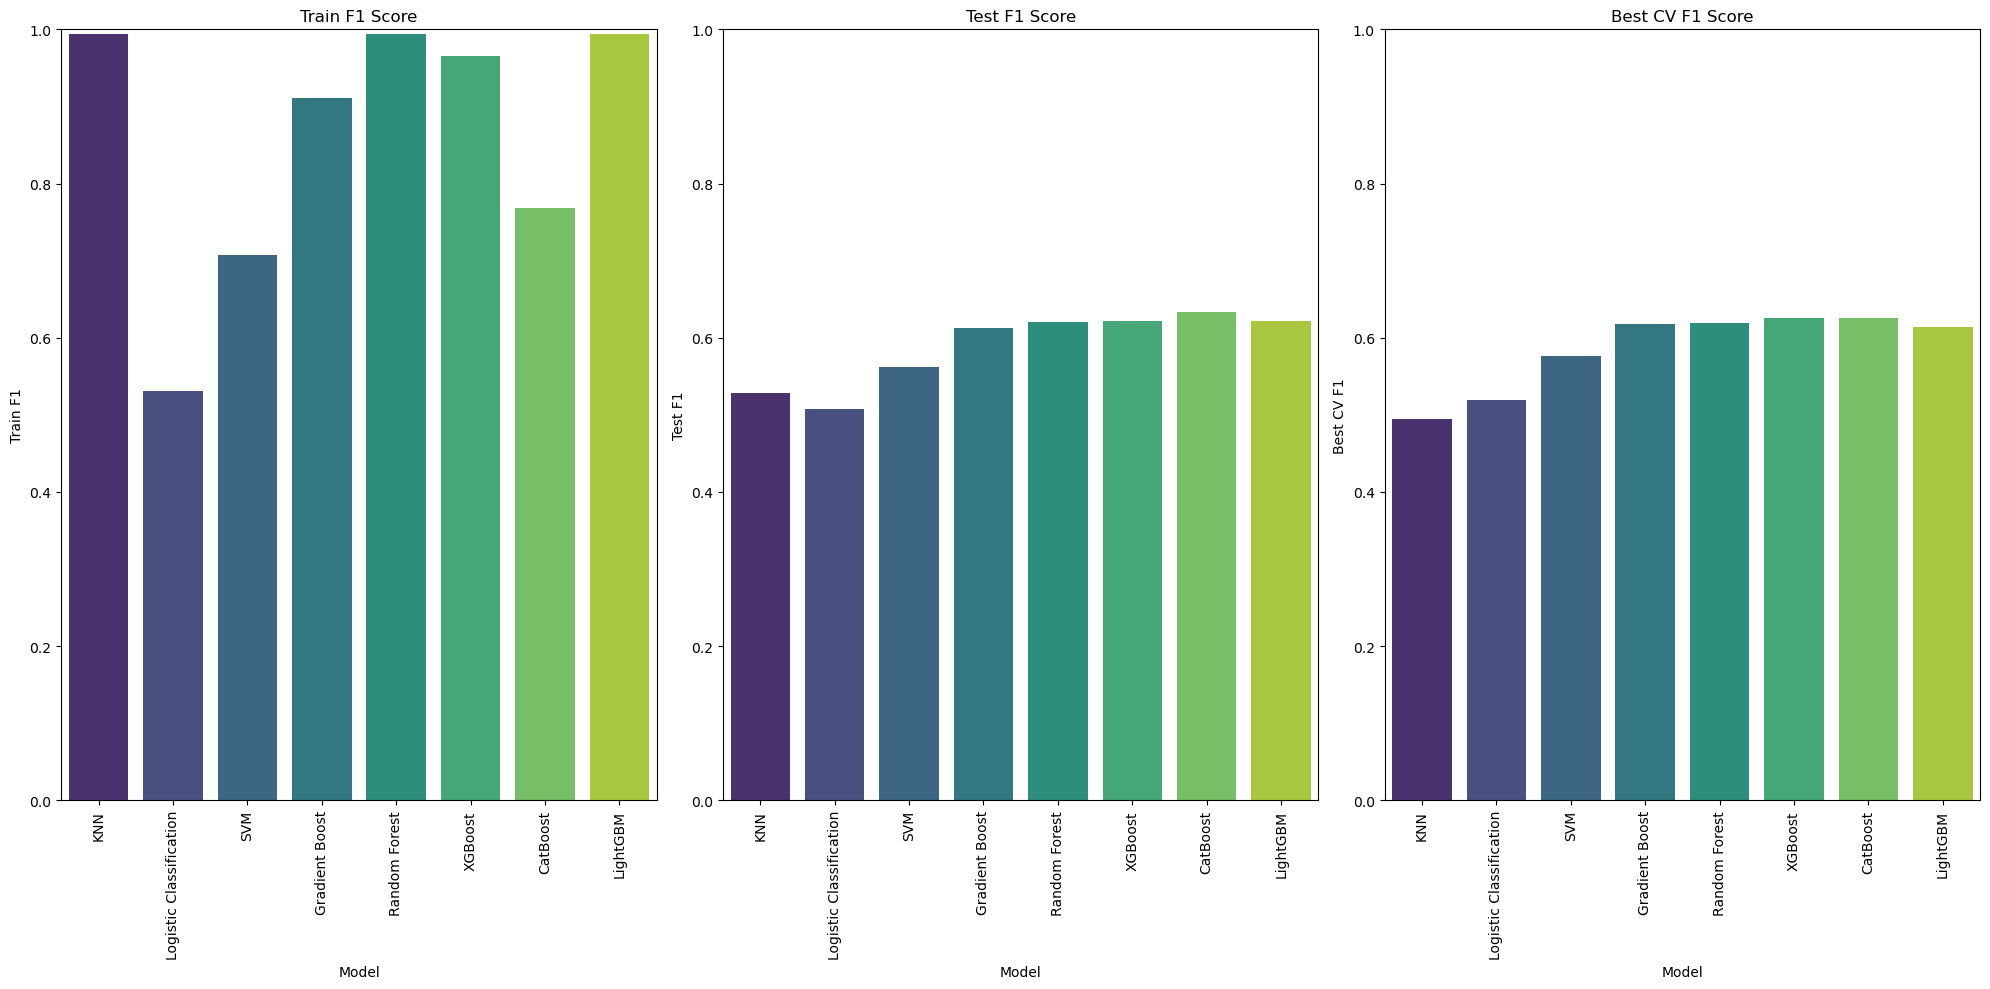

In [95]:
metrics = ['Train F1', 'Test F1', 'Best CV F1']
titles = ['Train F1 Score', 'Test F1 Score', 'Best CV F1 Score']

grid_df = all_results_df[all_results_df['Method'] == 'Grid Search']

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sns.barplot(data= grid_df, x='Model', y=metric, hue='Model', palette='viridis', legend=False, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# **Best Model Selection**
It seems CatBoost, XGBoost, and Random Forest are the top 3 models that can be purused further

# **Top Feature Selection**

In [96]:
feature_importances_df = pd.concat([
    gbc_feature_importances.rename('Gradient Boosting'),
    gbc_grid_feature_importances.rename('Gradient Boosting GridSearch'),
    rf_feature_importances.rename('Random Forest'),
    rf_grid_feature_importances.rename('Random Forest GridSearch'),
    xgbc_feature_importances.rename('XGBoost'),
    xgbc_grid_feature_importances.rename('XGBoost GridSearch'),
    cat_feature_importances.rename('CatBoost'),
    cat_grid_feature_importances.rename('CatBoost GridSearch'),
    lgbm_feature_importances.rename('LightGBM'),
    lgbm_grid_feature_importances.rename('LightGBM GridSeach'),
], axis=1).reset_index().rename(columns={'index': 'Feature'})

feature_importances_df.round(3)

,Feature,Gradient Boosting,Gradient Boosting GridSearch,Random Forest,Random Forest GridSearch,XGBoost,XGBoost GridSearch,CatBoost,CatBoost GridSearch,LightGBM,LightGBM GridSeach
0,danceability,0.084,0.077,0.100,0.100,0.080,0.093,0.096,0.083,0.097,0.106
1,energy,0.038,0.034,0.077,0.078,0.060,0.059,0.078,0.070,0.094,0.090
2,key,0.004,0.002,0.034,0.033,0.029,0.024,0.036,0.014,0.040,0.039
3,loudness,0.058,0.064,0.084,0.084,0.060,0.076,0.067,0.059,0.084,0.086
4,mode,0.001,0.001,0.010,0.011,0.035,0.032,0.012,0.005,0.008,0.007
5,speechiness,0.052,0.049,0.077,0.077,0.055,0.059,0.069,0.065,0.086,0.091
6,acousticness,0.045,0.041,0.073,0.072,0.045,0.044,0.068,0.068,0.092,0.092
7,instrumentalness,0.096,0.112,0.096,0.094,0.133,0.125,0.118,0.144,0.079,0.078
8,liveness,0.023,0.020,0.058,0.058,0.034,0.035,0.056,0.027,0.087,0.081
9,valence,0.048,0.032,0.072,0.071,0.055,0.056,0.069,0.047,0.088,0.086


In [112]:
best_models = ['CatBoost GridSearch', 'XGBoost GridSearch', 'Random Forest GridSearch']  # example names
selected_importances = feature_importances_df[['Feature'] + best_models]
selected_importances = selected_importances.sort_values(by='CatBoost GridSearch', ascending=False).reset_index(drop=True)
selected_importances

,Feature,CatBoost GridSearch,XGBoost GridSearch,Random Forest GridSearch
0,tempo,0.279881,0.208723,0.189462
1,instrumentalness,0.143701,0.125275,0.094010
2,duration_ms,0.139330,0.161874,0.127773
3,danceability,0.083163,0.093048,0.099661
4,energy,0.069529,0.058666,0.077727
5,acousticness,0.068103,0.044043,0.071908
6,speechiness,0.064782,0.059022,0.076929
7,loudness,0.058533,0.076153,0.084059
8,valence,0.047165,0.056417,0.071412
9,liveness,0.026812,0.034652,0.058326


In [98]:
top6_features = selected_importances['Feature'].head(6).tolist()


In [99]:
X_train_top6 = X_train[top6_features]
X_test_top6 = X_test[top6_features]

# **Running Best Models Using Top Features**

### **CatBoost**

In [106]:
cat_grid_best_params = cat_grid.best_params_
cat_grid_best_params

{'depth': 4, 'iterations': 300, 'learning_rate': 0.1}

In [107]:
cat_opt = CatBoostClassifier(**cat_grid_best_params, verbose = 0)
cat_opt.fit(X_train_top6, y_train)

In [108]:
f1_score(y_train, cat_opt.predict(X_train_top6), average = 'macro'), f1_score(y_test, cat_opt.predict(X_test_top6), average = 'macro')

(0.689013651207583, 0.6013228889906213)

### **XGBoost**

In [103]:
xgbc_grid_best_params = xgbc_grid.best_params_
xgbc_grid_best_params

{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1.0}

In [104]:
xgbc_opt = XGBClassifier(**xgbc_grid_best_params)
xgbc_opt.fit(X_train_top6, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [105]:
f1_score(y_train, xgbc_opt.predict(X_train_top6), average = 'macro'), f1_score(y_test, xgbc_opt.predict(X_test_top6), average = 'macro')

(0.8994009555138784, 0.5892501127203145)

Running these models with optimized parameters on selected top 6 features does not seem to have increased f1 score. So it is probably better to run the optimized models on the entire dataset


For deployment we will use the optimized gradient boosintg model


### **Random Forest**

In [113]:
rf_grid_best_params = rf_grid.best_params_
rf_grid_best_params

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 700}

In [114]:
rf_opt = RandomForestClassifier(**rf_grid_best_params)
rf_opt.fit(X_train_top6, y_train)

,n_estimators,700
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
f1_score(y_train, rf_opt.predict(X_train_top6), average = 'macro'), f1_score(y_test, rf_opt.predict(X_test_top6), average = 'macro')

(0.993746355767126, 0.58868590583344)

# **Deployment**

In [116]:
best_cat = cat_grid.best_estimator_

In [117]:
joblib.dump(best_cat, 'spotify_best_cat_boosting_model.pkl')

['spotify_best_cat_boosting_model.pkl']

In [118]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [119]:
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']